## Notebook 5 – Ensemble Learning

### 1. EXPLORATORY DATA ANALYSIS (EDA) + FEATURE INSIGHT

In [1]:
# Importing libraries

import pandas as pd
import numpy as np

from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, classification_report)
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, VotingClassifier, GradientBoostingClassifier,
                            AdaBoostClassifier)

from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(24)
# stores the randomely generated data in seed 24

In [2]:
# Importing dataframe from Notebook 4

df = pd.read_csv('CTR_Prediction_Dataframe_modified.csv').drop('Unnamed: 0', axis = 1)

df.head()

,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked,campaign_type_Search,campaign_type_Social,seasons_Spring,seasons_Summer,seasons_Winter,customer_segment_Returning,customer_segment_VIP,weekday_Weekend
0,1398.763652,50100.895666,27,0.698608,40.747007,0,0,False,False,False,False,True,False,True,False
1,768.989964,50610.176940,28,0.352786,71.475851,1,0,True,False,False,False,True,True,False,True
2,905.115892,46363.857264,42,0.535134,71.385886,0,0,False,True,False,False,True,True,False,False
3,702.756884,67688.402327,4,0.275047,63.096945,1,0,False,True,False,False,True,False,False,False
4,678.755123,22218.359496,45,0.816535,40.374703,1,0,False,True,False,True,False,True,False,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ad_budget                   5000 non-null   float64
 1   impressions                 5000 non-null   float64
 2   click_history               5000 non-null   int64  
 3   user_engagement_score       5000 non-null   float64
 4   time_on_site                5000 non-null   float64
 5   device_score                5000 non-null   int64  
 6   clicked                     5000 non-null   int64  
 7   campaign_type_Search        5000 non-null   bool   
 8   campaign_type_Social        5000 non-null   bool   
 9   seasons_Spring              5000 non-null   bool   
 10  seasons_Summer              5000 non-null   bool   
 11  seasons_Winter              5000 non-null   bool   
 12  customer_segment_Returning  5000 non-null   bool   
 13  customer_segment_VIP        5000 non-null   

In [4]:
print('Summary Statistics:\n') 
df.describe()

Summary Statistics:



,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,995.756272,49868.484588,24.660800,0.501541,60.127379,0.688000,0.116800
std,295.239804,14912.159593,14.396847,0.151293,19.971454,0.463356,0.321214
min,-21.458309,-4518.087037,0.000000,-0.046874,-9.760607,0.000000,0.000000
25%,796.705941,39833.664582,12.000000,0.400175,46.563899,0.000000,0.000000
50%,994.610605,49675.658556,25.000000,0.497377,59.810107,1.000000,0.000000
75%,1198.778488,59595.314140,37.000000,0.604109,73.922158,1.000000,0.000000
max,2298.900792,104357.414301,49.000000,1.049246,128.133075,1.000000,1.000000


### 2. STRATIFIED SHUFFLE SPLIT

In [5]:
X = df.drop('clicked', axis = 1)

y = df['clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 24,
    stratify = y
)

In [6]:
print(f'The split of X_train {X_train.shape} matches the split of y_train {y_train.shape}; while the split of X_test {X_test.shape} matches the split of y_test {y_test.shape}.')

The split of X_train (4000, 14) matches the split of y_train (4000,); while the split of X_test (1000, 14) matches the split of y_test (1000,).


In [7]:
print('Stratified share of y_train:\n', y_train.value_counts(normalize = True), '\n')
print('Stratified share of y_test:\n', y_test.value_counts(normalize = True))

Stratified share of y_train:
 clicked
0    0.88325
1    0.11675
Name: proportion, dtype: float64 

Stratified share of y_test:
 clicked
0    0.883
1    0.117
Name: proportion, dtype: float64


### 3. BASELINE MODEL (LOGISTIC REGRESSION)

__Ensemble modelling__ combines multiple machine learning models to produce a stronger overall predictor. Instead of relying on a single model, ensembles leverage the strengths of many models to improve accuracy, robustness, and generalisation.

While single Decision Trees are excellent because they are easy to visualise and interpret, they suffer from a fatal structural flaw: _extreme high variance_ (volatility)

__The Greediness Problem__: A single tree makes greedy mathematical cuts at every branch to maximise immediate information gain. Because of this, it is incredibly fragile. By changing just a few rows in training data, a single tree will completely alter its branching logic and generate a totally different flowchart.

__The Overfitting Trap__: As discovered in Notebook 4's depth experiment, an unconstrained tree will relentlessly grow until it perfectly memorises every outlier, anomaly, and bit of noise in the training set. It hits 100% training accuracy but falls apart on unseen test data.

__The Solution__: Ensemble models were invented specifically to rescue decision trees. By forcing a crowd of diverse trees to vote together, the individual errors, biases, and overfitted branches of lone trees cancel each other out, collapsing variance and driving testing scores up.

There are three major ensemble approaches covered in this notebook:

1. #### Bagging (Bootstrap Aggregating)

It trains dozens of trees simultaneously in parallel. Each tree gets a randomly sampled subset of data rows and columns.

Primary Example: __Random Forest__

Core Goal: `To reduce variance` (stops overfitting).

2. #### Boosting

It trains trees sequentially, one after the other. The first tree makes a fast guess. The second tree looks at where the first tree messed up and focuses entirely on fixing those specific mistakes. It repeats this chain-linking process hundreds of times.

Primary Examples: __AdaBoost, Gradient Boosting, and XGBoost__

Core Goal: `To reduce bias` (stops underfitting and pushes accuracy to its absolute maximum limit).

3. #### Voting

It combines predictions from different algorithms into one final prediction.

Primary Example: __Random Forest__

Core Goal: `To reduce variance and improve generalisation`

### 4. BAGGING FAMILY ENSEMBLING

* #### Bagging Classifier

It reduces variance by training multiple instances of the same base algorithm on different subsets of data

In [8]:
bagging_model = BaggingClassifier(
    estimator = DecisionTreeClassifier(),
    n_estimators = 50,
    # number of voting trees
    random_state = 24
)

bagging_model.fit(X_train, y_train)

bagging_proba = bagging_model.predict_proba(X_test)[:, 1]

print('Bagging ROC-AUC Score:', np.round(roc_auc_score(y_test, bagging_proba), 4))

Bagging ROC-AUC Score: 0.9859


* #### OOB Score

Bootstrap sampling randomly samples observations with replacement from the training data to create multiple different datasets. Each dataset is used to train a different model, encouraging diversity within the ensemble.

Out-of-Bag samples are observations not selected in a bootstrap sample.

In [9]:
bagging_oob_model = BaggingClassifier(
    estimator = DecisionTreeClassifier(),
    n_estimators = 100,
    oob_score = True,
    random_state = 24
)

bagging_oob_model.fit(X_train, y_train)

print('Bagging Out-of-Bag Score:', np.round(bagging_oob_model.oob_score_, 4))

Bagging Out-of-Bag Score: 0.9558


* #### Random Forest

It is a specialized, optimised version of a Bagging Classifier that uses decision trees as its base estimators.

In [10]:
rf_model = RandomForestClassifier(
    n_estimators = 200,
    # number of voting trees
    random_state = 24,
    n_jobs = -1
    # uses all CPU cores for high-speed processing
)

rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:,1]

print('Random Forest ROC-AUC Score:', np.round(roc_auc_score(y_test, rf_proba), 4))

Random Forest ROC-AUC Score: 0.9893


* #### Extra Trees Classifier

An Extra Trees Classifier takes randomness a step further than Random Forest to drastically speed up training and further reduce variance.
It chooses a split threshold completely at random for each feature candidate, then selects the best performing random split among them.

In [11]:
et_model = ExtraTreesClassifier(
    n_estimators = 200,
    random_state = 24,
    n_jobs = -1
)

et_model.fit(X_train, y_train)

et_proba = et_model.predict_proba(X_test)[:,1]

print('Extra Trees Classifier ROC-AUC Score:', np.round(roc_auc_score(y_test, et_proba), 4))

Extra Trees Classifier ROC-AUC Score: 0.9882


* #### Voting Classifier

It combines completely different machine learning algorithms rather than copying the same algorithm multiple times.

Hard vs Soft Voting

__Hard__ - Majority vote, uses predictions, simple                

__Soft__ - Average probabilities, uses confidence, usually better

In [12]:
voting_model = VotingClassifier(
    estimators = [
        ('rf', rf_model),
        # bagging model to reduce variance
        ('et', et_model),
        # bagging model to reduce variance
        ('gb', GradientBoostingClassifier(random_state = 24)),
        # boosting model to reduce bias
    ],
    voting = 'soft'
    # soft voting allows highly confident models to override uncertain ones
)

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict_proba(X_test)[:,1]

print('Voting Classifier ROC-AUC Score:', np.round(roc_auc_score(y_test, voting_pred), 4))

Voting Classifier ROC-AUC Score: 0.9946


### 5. BOOSTING FAMILY ENSEMBLING¶

* #### AdaBoost

It combines many 'weak learners' (models that perform just slightly better than random guessing) into a strong learner. 

In [13]:
ada_model = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth = 1),
    # maximum depth of 1, commonly known as a Decision Stump
    # A stump makes exactly one split on a single feature, dividing the data into two groups.
    n_estimators = 100,
    learning_rate = 0.1,
    # step size or contribution of each individual tree to the final prediction set
    random_state = 24
)

ada_model.fit(X_train, y_train)

ada_proba = ada_model.predict_proba(X_test)[:, 1]

print('Ada Boost Classifier ROC-AUC Score:', np.round(roc_auc_score(y_test, ada_proba), 4))

Ada Boost Classifier ROC-AUC Score: 0.9735


* #### GradientBoost

It learns the residual errors. Each new tree predicts what previous trees got wrong.

In [14]:
gb_model = GradientBoostingClassifier(random_state = 24)

gb_model.fit(X_train, y_train)

gb_proba = gb_model.predict_proba(X_test)[:,1]

print('Gradient Boosting Classifier ROC-AUC Score:', np.round(roc_auc_score(y_test, gb_proba), 4))

Gradient Boosting Classifier ROC-AUC Score: 0.9943


* #### XGBoost (Extreme Gradient Boosting) 

It is an optimised implementation of Gradient Boosting designed for speed, scalability, and accuracy.

In [15]:
xgb_model = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 4,
    eval_metric = 'logloss',
    # Logarithmic Loss is a performance metric that heavily penalises overconfident models
    random_state = 24,
)

xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:,1]

print('XGBoost Classifier ROC-AUC Score:', np.round(roc_auc_score(y_test, xgb_proba), 4))

XGBoost Classifier ROC-AUC Score: 0.9957


### 6. CROSS VALIDATION

In [16]:
# Defining Voting Classifier using existing models

cv_results = []

final_voting_model = VotingClassifier(
    estimators = [
        ('Bagging', bagging_model),
        ('Random Forest', rf_model),
        ('Extra Trees', et_model),
        ('AdaBoost', ada_model),
        ('GradientBoost', gb_model),
        ('XGBoost', xgb_model)
    ],
    voting = 'soft'
)

models = {
    'Bagging': bagging_model,
    'Random Forest': rf_model,
    'Extra Trees': et_model,
    'AdaBoost': ada_model,
    'GradientBoost': gb_model,
    'XGBoost': xgb_model,
    'Voting': final_voting_model
}

cv = StratifiedKFold(
    n_splits = 5, shuffle = True, random_state = 24
)

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv = cv, scoring = 'roc_auc')
    cv_results.append([name, cv_scores.mean(), cv_scores.std()])

df_results = pd.DataFrame(cv_results, columns = ['Model_Name', 'CV_Mean_Score', 'CV_Std_Score'])

df_results.sort_values(by = 'CV_Mean_Score', ascending = False)

,Model_Name,CV_Mean_Score,CV_Std_Score
5,XGBoost,0.994599,0.001180
6,Voting,0.993124,0.001478
4,GradientBoost,0.992016,0.002304
1,Random Forest,0.989769,0.001924
2,Extra Trees,0.984580,0.002216
0,Bagging,0.983309,0.003802
3,AdaBoost,0.966610,0.004024


### 7. ROC CURVE COMPARISON

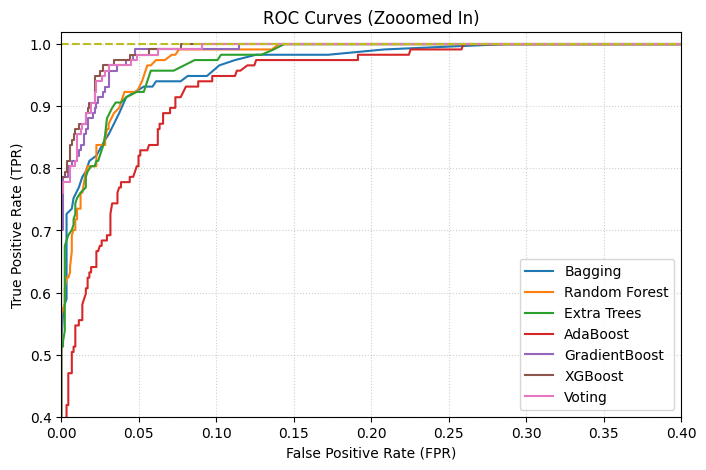

In [17]:
# Generating probability for final voting model

final_voting_model.fit(X_train, y_train)

f_voting_proba = final_voting_model.predict_proba(X_test)[:,1]

# Creating dictionary of probabilities

probabilities = {
    'Bagging': bagging_proba,
    'Random Forest': rf_proba,
    'Extra Trees': et_proba,
    'AdaBoost': ada_proba,
    'GradientBoost': gb_proba,
    'XGBoost': xgb_proba,
    'Voting': f_voting_proba
}

plt.figure(figsize = (8,5))

for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    # fpr = False Positive Rate
    # tpr = True Positive Rate
    # _ =  classification thresholds used to calculate fpr, tpr
    # assigned to an underscore placeholder since not required for plotting purpose
    plt.plot(fpr, tpr, label = name)

plt.plot([[0,1], [0,1]], linestyle = '--')

# Instead of showing 0 to 1, the area where lines curves is zoomed in
plt.xlim([0.0, 0.4])
plt.ylim([0.4, 1.02])

plt.title('ROC Curves (Zooomed In)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')

plt.grid(alpha = 0.6, linestyle = ':')
plt.legend()
plt.show();

### 8. PRECISION-RECALL CURVE

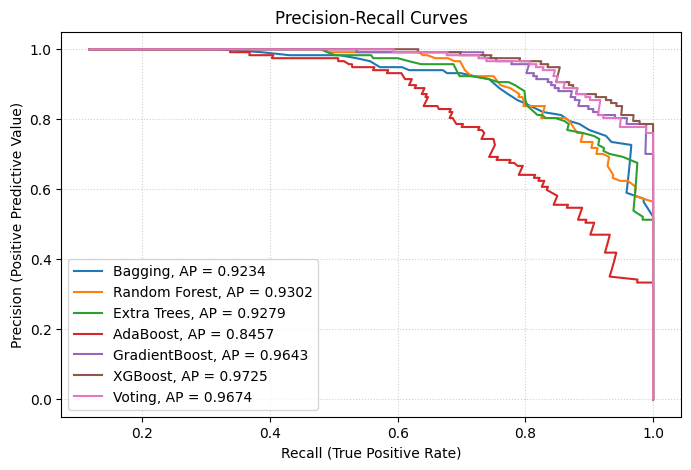

In [18]:
plt.figure(figsize = (8,5))

for name, proba in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(precision, recall, label = f'{name}, AP = {ap:.4f}')

plt.title('Precision-Recall Curves')
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')

plt.legend()
plt.grid(linestyle = ':', alpha = 0.6)
plt.show();

### 9. FEATURE IMPORTANCE (TREE MODELS)

In [19]:
# Calculating Bagging feature importances by averaging its internal estimators
bagging_model_feature_importances_ = np.mean(
    [tree.feature_importances_ for tree in bagging_model.estimators_], axis=0
)

# Calculating Soft Voting feature importances by averaging its base models
final_voting_model_feature_importances_ = np.mean([
    rf_model.feature_importances_,
    et_model.feature_importances_,
    gb_model.feature_importances_
], axis=0)

# Building the final dataFrame
importances = pd.DataFrame({
    'Bagging': bagging_model_feature_importances_,
    'Random Forest': rf_model.feature_importances_,
    'Extra Trees': et_model.feature_importances_,
    'AdaBoost': ada_model.feature_importances_,
    'GradientBoost': gb_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_,          
    'Voting': final_voting_model_feature_importances_
}, index=X.columns)


pd.DataFrame(importances)

,Bagging,Random Forest,Extra Trees,AdaBoost,GradientBoost,XGBoost,Voting
ad_budget,0.326380,0.334637,0.272908,0.589535,0.423539,0.231153,0.343694
impressions,0.067166,0.084958,0.090219,0.000000,0.023579,0.061397,0.066252
click_history,0.218626,0.180818,0.178990,0.195097,0.264472,0.175932,0.208093
user_engagement_score,0.186215,0.185432,0.164058,0.139560,0.198738,0.130958,0.182742
time_on_site,0.116967,0.103941,0.101361,0.027386,0.045641,0.093820,0.083647
device_score,0.055589,0.030722,0.034766,0.048421,0.042853,0.191970,0.036114
campaign_type_Search,0.002893,0.009340,0.022077,0.000000,0.000217,0.012169,0.010545
campaign_type_Social,0.003649,0.009981,0.017822,0.000000,0.000458,0.007782,0.009420
seasons_Spring,0.002554,0.008827,0.018509,0.000000,0.000000,0.009136,0.009112
seasons_Summer,0.005053,0.009872,0.018134,0.000000,0.000000,0.026364,0.009335


### 10. FINAL MODEL SELECTION

In [20]:
df_results.sort_values(by = 'CV_Mean_Score', ascending = False).head(1)

,Model_Name,CV_Mean_Score,CV_Std_Score
5,XGBoost,0.994599,0.00118


__Key Takeaways__

XGBoost is best-performing model based on aboveresults. It achieved both the highest overall performance (0.9946 ROC-AUC) and the lowest variation (0.0011 standard deviation), meaning it is highly stable across different folds.

In [21]:
print('Final ROC-AUC:', np.round(roc_auc_score(y_test, xgb_proba), 4), '\n')
print('XGBoost Classification Report:\n', classification_report(y_test, xgb_model.predict(X_test)))

Final ROC-AUC: 0.9957 

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       883
           1       0.95      0.82      0.88       117

    accuracy                           0.97      1000
   macro avg       0.96      0.91      0.93      1000
weighted avg       0.97      0.97      0.97      1000

